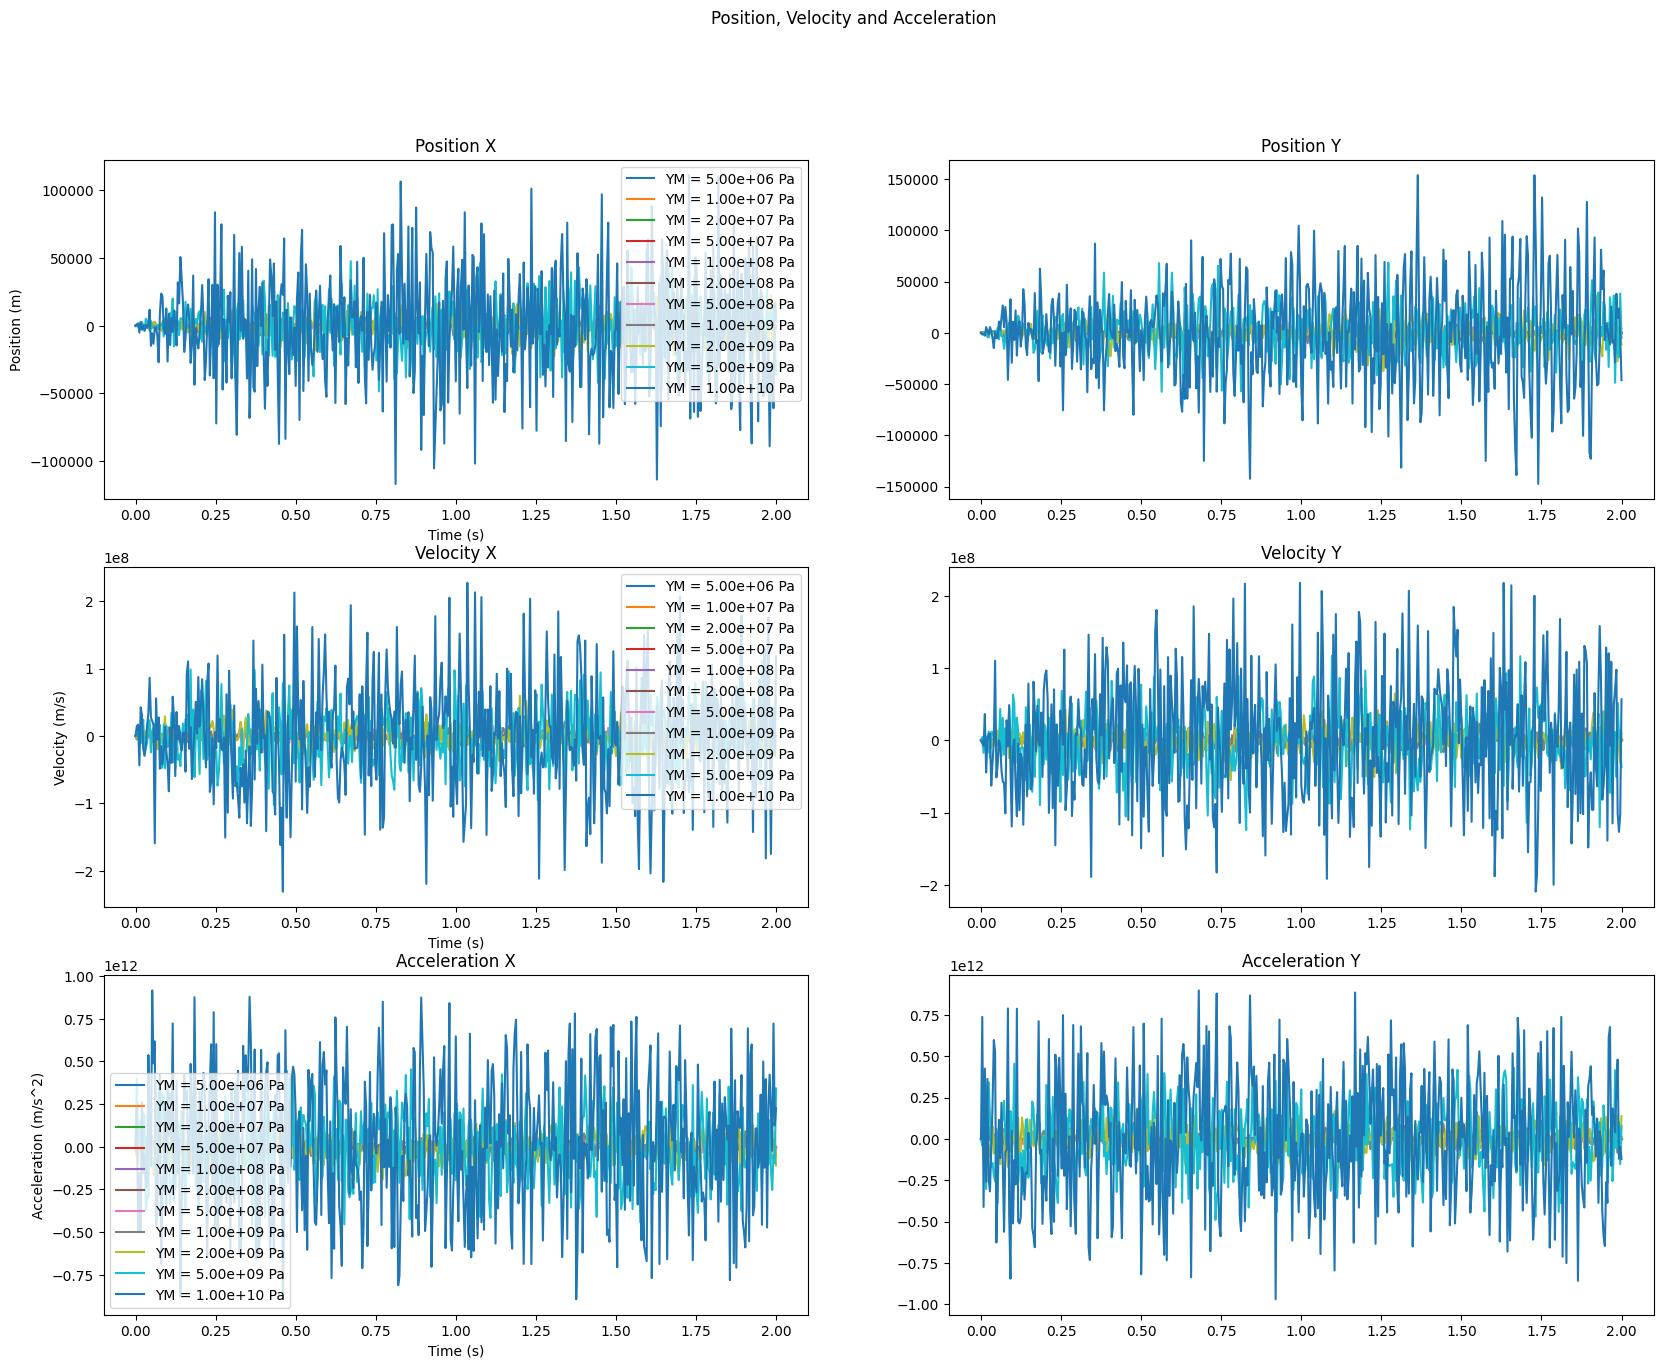

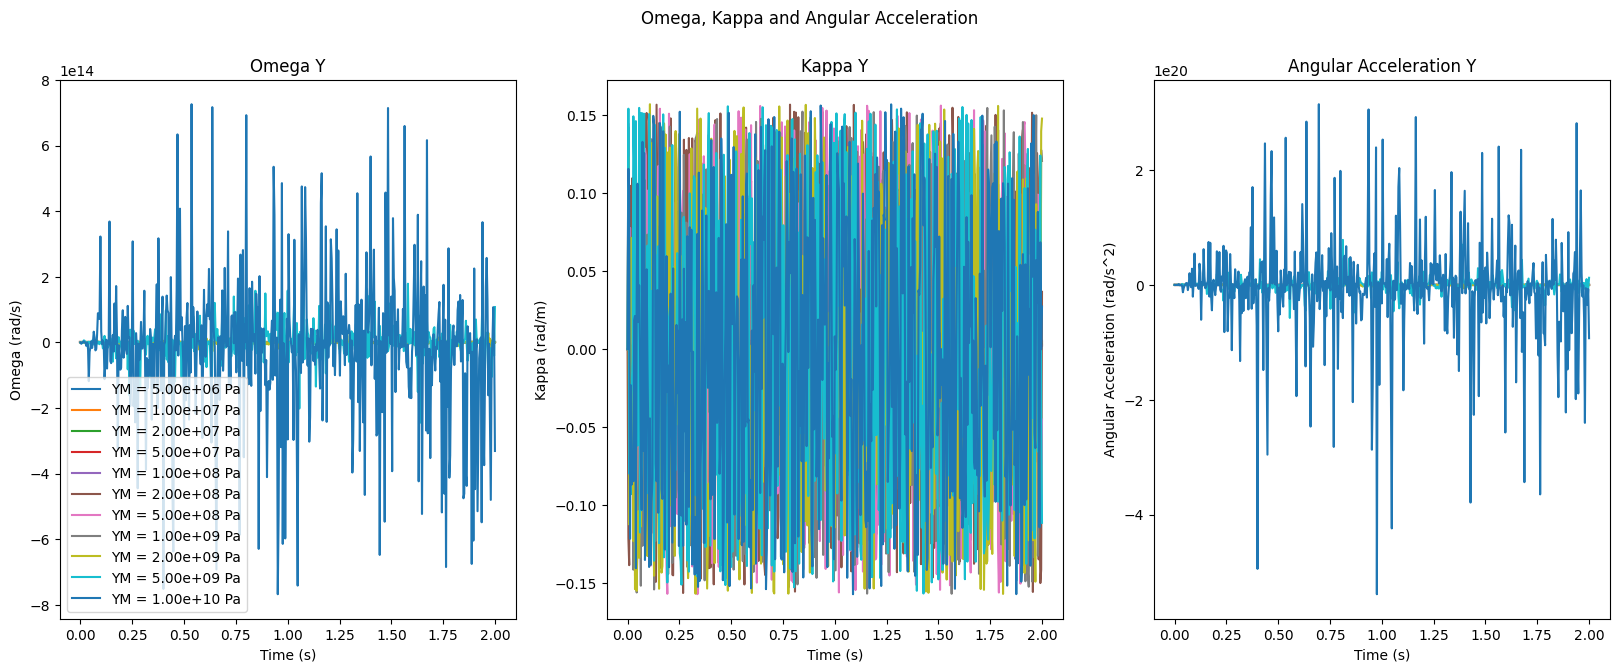

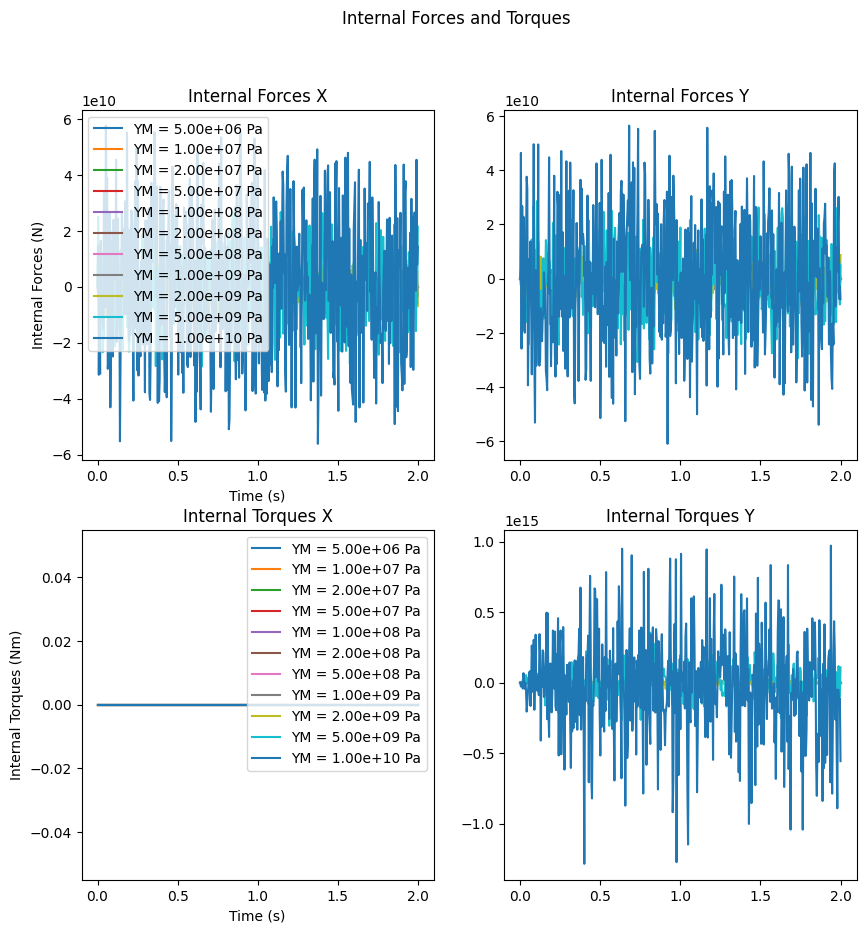

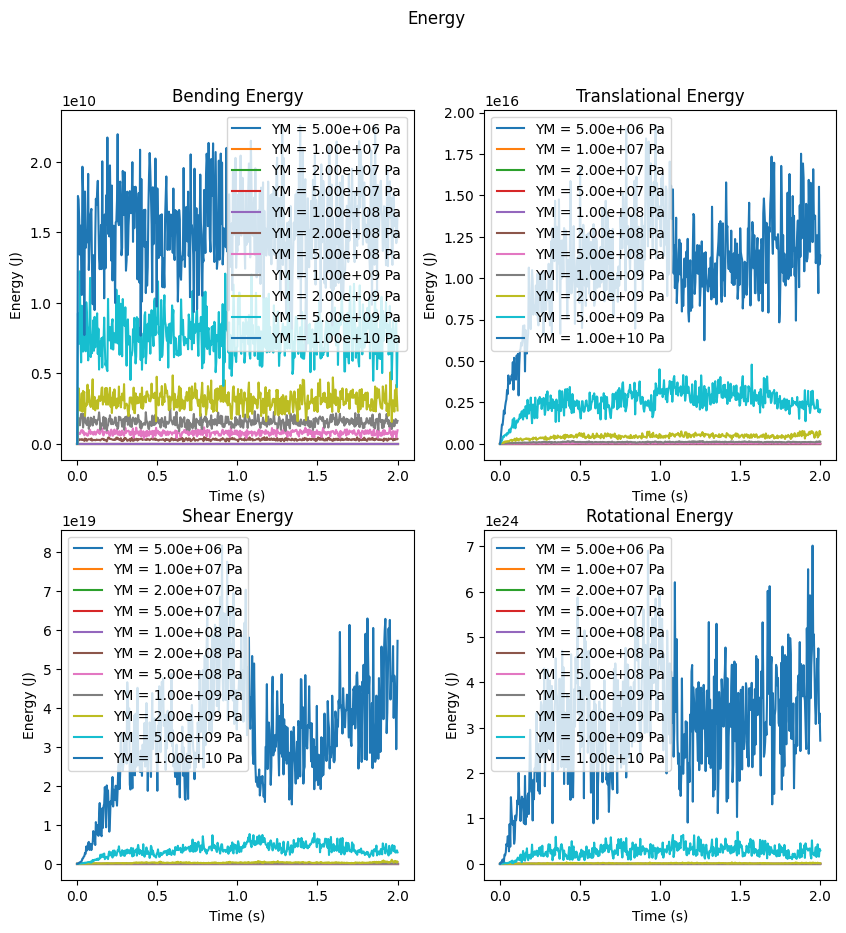

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(3, 2, figsize=(20, 15))
fig2, ax2 = plt.subplots(1, 3, figsize=(20, 7))
fig3, ax3 = plt.subplots(2, 2, figsize=(10, 10))
fig4, ax4 = plt.subplots(2, 2, figsize=(10, 10))

scaling_type = "mm_g_s"
modulus = [5e6, 10e6, 20e6, 50e6, 100e6, 200e6, 500e6, 1e9, 2e9, 5e9, 10e9]
df = {}
for ym in modulus:
    params = {
        'num_horizontal_threads': 1,
        'num_vertical_threads': 0,
        'network_origin': np.zeros((3,)), # network_origin is the center of the network

        'thread_length': 500e-3, # 1 m --> 1e3 mm
        'thread_diameter': 2e-3, # 1 m --> 1e3 mm
        'dx': 20e-3, # 1 m --> 1e3 mm

        'youngs_modulus': ym, # 1 Pa = kg /m/s2 --> 1 g/mm/s2 --> 1e-3 mg/mm/ms2
        'density': 1e3, # 1 kg / mm3 --> 1e-6 g/mm3 --> 1e-3 mg/mm3

        'tension_force': 1e-2, # 1 N = kg m/s2 --> 1e6 g mm/s2 --> 1e3 mg mm /ms2  
        'point_force_mag': -5e-3, #-5e-3, # 1 N = kg m/s2 --> 1e6 g mm/s2 --> 1e3 mg mm /ms2 
        'SPREAD_PF': True, # whether the force should be a gaussian spread across 5 nodes or just applied at a single point
        'TYPE_PF': "constant", # type of force to be applied 
        'sample_freq_pf': 5, # Sampling frequency for random point force

        'damping_constant': 10, 
        # 'filter_order': 6,

        'k': 1e9, # translational stiffness of connection
        'kt': 1e9, # rotational stiffness of connection
        'nu': 0.0, # translational damping of connection

        'duration': 2, # 1 s --> 1e3 ms
        'sim_dt': 5e-6, # simulation timestep

        'rendering_fps': 250,
        
        'STOP_AT_NAN': False,
        'SAVE': True,
        'VIDEO': True,

        'scaling_type': scaling_type,
        'loc': './YMvariation/',
        'file_type': 'npz'
    }

    step_skip = np.rint(1.0 / (params['sim_dt'] * params['rendering_fps'])).astype(int)

    suffix = f"{params['duration']:.0f}sec_L{params['thread_length']:.2e}m_R{params['thread_diameter']/2:.2e}m_dx{params['dx']*1e3:.0f}mm_YM{params['youngs_modulus']:.2e}Pa_Density{params['density']:.2e}kgmm-3_Damping{params['damping_constant']:.0f}_TF{params['tension_force']:.0e}N_PF{params['point_force_mag']:.0e}N{params['TYPE_PF']}_k{params['k']:.0e}_kt{params['kt']:.0e}_fps{params['rendering_fps']}_stepskip{step_skip:.0f}"
    name = f"{params['scaling_type']}_FiberSim_{params['num_horizontal_threads']+params['num_vertical_threads']}rods_{suffix}"

    # Load data
    data = np.load(f"{params['loc']}{name}.{params['file_type']}", allow_pickle=True)
    rods_history = data['rods_history']
    rods_history = rods_history[0]
    df[ym] = {}
    n_elem = rods_history['position'][0].shape[1]
    center_elem = np.rint(n_elem / 2).astype(int)
    df[ym]['time'] = rods_history['time']
    df[ym]['position'] = [rods_history['position'][i][:, center_elem] for i in range(len(rods_history['position']))]
    df[ym]['velocity'] = [rods_history['velocity_collection'][i][:, center_elem] for i in range(len(rods_history['velocity_collection']))]
    df[ym]['acceleration'] = [rods_history['acceleration_collection'][i][:, center_elem] for i in range(len(rods_history['acceleration_collection']))]
    df[ym]['omega'] = [rods_history['omega_collection'][i][:, center_elem] for i in range(len(rods_history['omega_collection']))]
    df[ym]['kappa'] = [rods_history['kappa'][i][:, center_elem] for i in range(len(rods_history['kappa']))]
    df[ym]['angular_acceleration'] = [rods_history['angular_acceleration'][i][:, center_elem] for i in range(len(rods_history['angular_acceleration']))]
    df[ym]['internal_forces'] = [rods_history['internal_forces'][i][:, center_elem] for i in range(len(rods_history['internal_forces']))]
    df[ym]['external_forces'] = [rods_history['external_forces'][i][:, center_elem] for i in range(len(rods_history['external_forces']))]
    df[ym]['internal_torques'] = [rods_history['internal_torques'][i][:, center_elem] for i in range(len(rods_history['internal_torques']))]
    df[ym]['external_torques'] = [rods_history['external_torques'][i][:, center_elem] for i in range(len(rods_history['external_torques']))]
    df[ym]['bending_energy'] = rods_history['bending_energy']
    df[ym]['translational_energy'] = rods_history['translational_energy']
    df[ym]['shear_energy'] = rods_history['shear_energy']
    df[ym]['rotational_energy'] = rods_history['rotational_energy']

    # Plotting
    # Position
    ax1[0, 0].plot(df[ym]['time'], [df[ym]['position'][i][0] for i in range(len(df[ym]['position']))], label=f"YM = {ym:.2e} Pa")
    ax1[0, 1].plot(df[ym]['time'], [df[ym]['position'][i][1] for i in range(len(df[ym]['position']))], label=f"YM = {ym:.2e} Pa")
    # Velocity
    ax1[1, 0].plot(df[ym]['time'], [df[ym]['velocity'][i][0] for i in range(len(df[ym]['velocity']))], label=f"YM = {ym:.2e} Pa")
    ax1[1, 1].plot(df[ym]['time'], [df[ym]['velocity'][i][1] for i in range(len(df[ym]['velocity']))], label=f"YM = {ym:.2e} Pa")
    # Acceleration
    ax1[2, 0].plot(df[ym]['time'], [df[ym]['acceleration'][i][0] for i in range(len(df[ym]['acceleration']))], label=f"YM = {ym:.2e} Pa")
    ax1[2, 1].plot(df[ym]['time'], [df[ym]['acceleration'][i][1] for i in range(len(df[ym]['acceleration']))], label=f"YM = {ym:.2e} Pa")

    # Omeg
    ax2[0].plot(df[ym]['time'], [df[ym]['omega'][i][1] for i in range(len(df[ym]['omega']))], label=f"YM = {ym:.2e} Pa")
    # Kappa
    ax2[1].plot(df[ym]['time'], [df[ym]['kappa'][i][1] for i in range(len(df[ym]['kappa']))], label=f"YM = {ym:.2e} Pa")
    # Angular Acceleration
    ax2[2].plot(df[ym]['time'], [df[ym]['angular_acceleration'][i][1] for i in range(len(df[ym]['angular_acceleration']))], label=f"YM = {ym:.2e} Pa")

    # Internal Forces
    ax3[0, 0].plot(df[ym]['time'], [df[ym]['internal_forces'][i][0] for i in range(len(df[ym]['internal_forces']))], label=f"YM = {ym:.2e} Pa")
    ax3[0, 1].plot(df[ym]['time'], [df[ym]['internal_forces'][i][1] for i in range(len(df[ym]['internal_forces']))], label=f"YM = {ym:.2e} Pa")
    # Internal Torques
    ax3[1, 0].plot(df[ym]['time'], [df[ym]['internal_torques'][i][0] for i in range(len(df[ym]['internal_torques']))], label=f"YM = {ym:.2e} Pa")
    ax3[1, 1].plot(df[ym]['time'], [df[ym]['internal_torques'][i][1] for i in range(len(df[ym]['internal_torques']))], label=f"YM = {ym:.2e} Pa")

    # Bending Energy
    ax4[0, 0].plot(df[ym]['time'], df[ym]['bending_energy'], label=f"YM = {ym:.2e} Pa")
    # Translational Energy
    ax4[0, 1].plot(df[ym]['time'], df[ym]['translational_energy'], label=f"YM = {ym:.2e} Pa")
    # Shear Energy
    ax4[1, 0].plot(df[ym]['time'], df[ym]['shear_energy'], label=f"YM = {ym:.2e} Pa")
    # Rotational Energy
    ax4[1, 1].plot(df[ym]['time'], df[ym]['rotational_energy'], label=f"YM = {ym:.2e} Pa")

ax1[0, 0].set_title("Position X")
ax1[0, 1].set_title("Position Y")
ax1[1, 0].set_title("Velocity X")
ax1[1, 1].set_title("Velocity Y")
ax1[2, 0].set_title("Acceleration X")
ax1[2, 1].set_title("Acceleration Y")
ax1[0, 0].legend()
ax1[0, 0].set_xlabel("Time (s)")
ax1[0, 0].set_ylabel("Position (m)")
ax1[1, 0].legend()
ax1[1, 0].set_xlabel("Time (s)")
ax1[1, 0].set_ylabel("Velocity (m/s)")
ax1[2, 0].legend()
ax1[2, 0].set_xlabel("Time (s)")
ax1[2, 0].set_ylabel("Acceleration (m/s^2)")
fig1.suptitle("Position, Velocity and Acceleration")

ax2[0].set_title("Omega Y")
ax2[1].set_title("Kappa Y")
ax2[2].set_title("Angular Acceleration Y")
ax2[0].legend()
ax2[0].set_xlabel("Time (s)")
ax2[0].set_ylabel("Omega (rad/s)")
ax2[1].set_xlabel("Time (s)")
ax2[1].set_ylabel("Kappa (rad/m)")
ax2[2].set_xlabel("Time (s)")
ax2[2].set_ylabel("Angular Acceleration (rad/s^2)")
fig2.suptitle("Omega, Kappa and Angular Acceleration")

ax3[0, 0].set_title("Internal Forces X")
ax3[0, 1].set_title("Internal Forces Y")
ax3[0, 0].legend()
ax3[0, 0].set_xlabel("Time (s)")
ax3[0, 0].set_ylabel("Internal Forces (N)")
ax3[1, 0].set_title("Internal Torques X")
ax3[1, 1].set_title("Internal Torques Y")
ax3[1, 0].legend()
ax3[1, 0].set_xlabel("Time (s)")
ax3[1, 0].set_ylabel("Internal Torques (Nm)")
fig3.suptitle("Internal Forces and Torques")

ax4[0, 0].set_title("Bending Energy")
ax4[0, 1].set_title("Translational Energy")
ax4[1, 0].set_title("Shear Energy")
ax4[1, 1].set_title("Rotational Energy")
ax4[0, 0].legend()
ax4[0, 0].set_xlabel("Time (s)")
ax4[0, 0].set_ylabel("Energy (J)")
ax4[0, 1].legend()
ax4[0, 1].set_xlabel("Time (s)")
ax4[0, 1].set_ylabel("Energy (J)")
ax4[1, 0].legend()
ax4[1, 0].set_xlabel("Time (s)")
ax4[1, 0].set_ylabel("Energy (J)")
ax4[1, 1].legend()
ax4[1, 1].set_xlabel("Time (s)")
ax4[1, 1].set_ylabel("Energy (J)")
fig4.suptitle("Energy")

plt.show()  # Show all figures

In [2]:
l1 = -(4*60338075084384497778845721627093**(1/2)*((12580614987318048588671658588190651328296555137466368*103301806934315028209603530300196096456476812623800529525590201**(1/2))/7134481141171517 + 127866221165746278008978870514471853841248145157634046725346888974588517446173907057/7134481141171517)**(1/2))/60338075084384497778845721627093
l2 = (4*60338075084384497778845721627093**(1/2)*((12580614987318048588671658588190651328296555137466368*103301806934315028209603530300196096456476812623800529525590201**(1/2))/7134481141171517 + 127866221165746278008978870514471853841248145157634046725346888974588517446173907057/7134481141171517)**(1/2))/60338075084384497778845721627093
l3 = -(4*60338075084384497778845721627093**(1/2)*(127866221165746278008978870514471853841248145157634046725346888974588517446173907057/7134481141171517 - (12580614987318048588671658588190651328296555137466368*103301806934315028209603530300196096456476812623800529525590201**(1/2))/7134481141171517)**(1/2))/60338075084384497778845721627093
l4 = (4*60338075084384497778845721627093**(1/2)*(127866221165746278008978870514471853841248145157634046725346888974588517446173907057/7134481141171517 - (12580614987318048588671658588190651328296555137466368*103301806934315028209603530300196096456476812623800529525590201**(1/2))/7134481141171517)**(1/2))/60338075084384497778845721627093

In [3]:
print(l1, l2, l3, l4)

-3.083017442271255e+18 3.083017442271255e+18 (-1.7250820296029487e-06-28172727529.34181j) (1.7250820296029487e-06+28172727529.34181j)
